# Support Vector Machines: Margins and Support Vectors

---

## Margins conversation

In a **linear SVM** we seek the hyperplane that **maximizes the margin**—the distance from the decision boundary to the nearest training points. The points that lie exactly on the margin boundaries are called **support vectors**: they *support* the margin and uniquely define the optimal hyperplane. *Only these points influence the final model; moving or removing any other point leaves the solution unchanged.*

### Illustrate with a simple example

The cell below builds a small synthetic dataset (two linearly separable blobs), fits a **linear SVM**, and plots the result. In the figure: the **decision boundary** is the solid line—the hyperplane \(w \cdot x + b = 0\) that separates the two classes; the **margin** is the region between \(w \cdot x + b = \pm 1\) (dashed lines and shaded band), with width \(2/\|w\|\); and the **support vectors** are the large circles with thick borders—the training points on the margin that alone determine the optimal hyperplane.

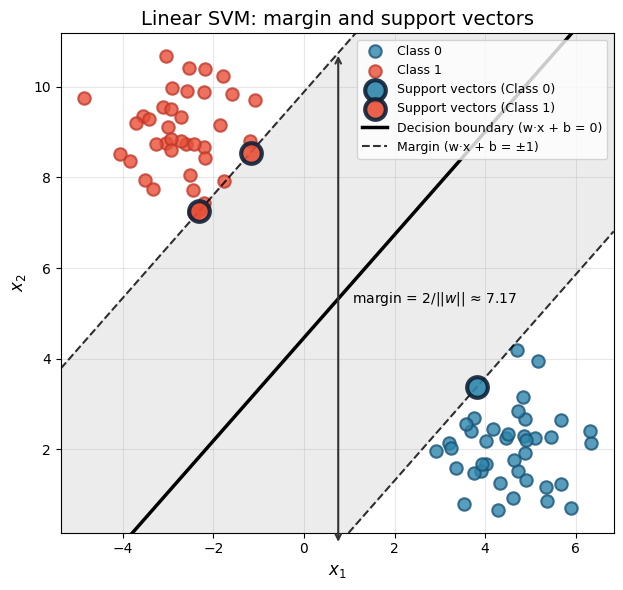

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_blobs

# Create a simple 2D linearly separable dataset
X, y = make_blobs(n_samples=80, centers=2, n_features=2, random_state=42, cluster_std=0.9)
# Flip labels so we have nice class 0 vs 1 (blobs sometimes give -1, 1)
y = (y == 0).astype(int)

# Fit linear SVM with C large so we get a hard margin (clear margin)
clf = SVC(kernel='linear', C=1e4)
clf.fit(X, y)

# Decision boundary: w·x + b = 0  =>  x2 = (-w1*x1 - b) / w2
w = clf.coef_[0]
b = clf.intercept_[0]
x1_min, x1_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
x1_line = np.linspace(x1_min, x1_max, 300)
x2_decision = -(w[0] * x1_line + b) / w[1]

# Margin boundaries: w·x + b = ±1  =>  x2 = (-w1*x1 - b ± 1) / w2
x2_margin_plus  = -(w[0] * x1_line + b - 1) / w[1]
x2_margin_minus = -(w[0] * x1_line + b + 1) / w[1]

# Support vectors
sv = clf.support_vectors_
sv_labels = y[clf.support_]

fig, ax = plt.subplots(1, 1, figsize=(9, 6))

# Class 0 and Class 1 (non-SV)
mask0 = (y == 0) & ~np.isin(np.arange(len(y)), clf.support_)
mask1 = (y == 1) & ~np.isin(np.arange(len(y)), clf.support_)
ax.scatter(X[mask0, 0], X[mask0, 1], c='#2E86AB', s=80, alpha=0.8, edgecolors='#1a5276', linewidths=1.5, label='Class 0', zorder=2)
ax.scatter(X[mask1, 0], X[mask1, 1], c='#E94F37', s=80, alpha=0.8, edgecolors='#c0392b', linewidths=1.5, label='Class 1', zorder=2)

# Support vectors (highlighted)
ax.scatter(sv[sv_labels == 0, 0], sv[sv_labels == 0, 1], c='#2E86AB', s=220, alpha=0.9, edgecolors='#0d2137', linewidths=3, marker='o', label='Support vectors (Class 0)', zorder=4)
ax.scatter(sv[sv_labels == 1, 0], sv[sv_labels == 1, 1], c='#E94F37', s=220, alpha=0.9, edgecolors='#0d2137', linewidths=3, marker='o', label='Support vectors (Class 1)', zorder=4)

# Margin band (shaded)
ax.fill_between(x1_line, x2_margin_minus, x2_margin_plus, color='gray', alpha=0.15, zorder=0)

# Decision boundary and margin lines
ax.plot(x1_line, x2_decision, 'k-', lw=2.5, label='Decision boundary (w·x + b = 0)', zorder=3)
ax.plot(x1_line, x2_margin_plus, 'k--', lw=1.5, alpha=0.8, label='Margin (w·x + b = ±1)')
ax.plot(x1_line, x2_margin_minus, 'k--', lw=1.5, alpha=0.8)

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
ax.set_xlabel('$x_1$', fontsize=12)
ax.set_ylabel('$x_2$', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.set_title('Linear SVM: margin and support vectors', fontsize=14)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
# Annotate margin width (geometric margin = 2/||w||)
margin_width = 2.0 / np.linalg.norm(w)
mid_idx = len(x1_line) // 2
x_mid, y_mid = x1_line[mid_idx], (x2_margin_plus[mid_idx] + x2_margin_minus[mid_idx]) / 2
ax.annotate('', xy=(x_mid, x2_margin_plus[mid_idx]), xytext=(x_mid, x2_margin_minus[mid_idx]),
            arrowprops=dict(arrowstyle='<->', color='#333', lw=1.5))
ax.text(x_mid + 0.3, y_mid, f'margin = $2/||w||$ ≈ {margin_width:.2f}', fontsize=10, va='center')
plt.tight_layout()
plt.show()

## Soft margin and the regularization parameter C

---

### Soft margin

A **hard-margin** SVM requires every training point to be correctly classified and to lie outside or on the margin. When the data are not perfectly linearly separable—because of noise or overlap—no such hyperplane exists and the optimization has no solution.

The **soft-margin** formulation relaxes this by introducing **slack variables** \(\xi_i \geq 0\). Each \(\xi_i\) measures how much a point may violate the margin or be misclassified. We then solve:

> **Minimize** \(\displaystyle\frac{1}{2}\|w\|^2 + C \sum_i \xi_i\)  
> subject to \(y_i(w \cdot x_i + b) \geq 1 - \xi_i\).

So: points with \(\xi_i = 0\) are correctly classified and outside or on the margin; with \(0 < \xi_i < 1\) they lie inside the margin but on the correct side; with \(\xi_i \geq 1\) they may be misclassified. *The soft margin thus trades some misclassifications and margin violations for a usable separating hyperplane when the data are noisy or overlapping.*

---

### Role of the regularization parameter C

**C** controls the trade-off between **maximizing the margin** (minimizing \(\|w\|^2\): larger margin, simpler boundary) and **minimizing errors and violations** (minimizing \(\sum_i \xi_i\): fewer mistakes on the training set).

With **large C**, slack is penalized heavily: the model tries to classify almost every point correctly, the margin can shrink, and the boundary may overfit. With **small C**, slack is penalized less: more violations are tolerated, the margin widens, and the boundary tends to be smoother—often with better generalization. A **medium C** balances margin width and training accuracy. In practice, C is usually chosen by cross-validation or other model selection.

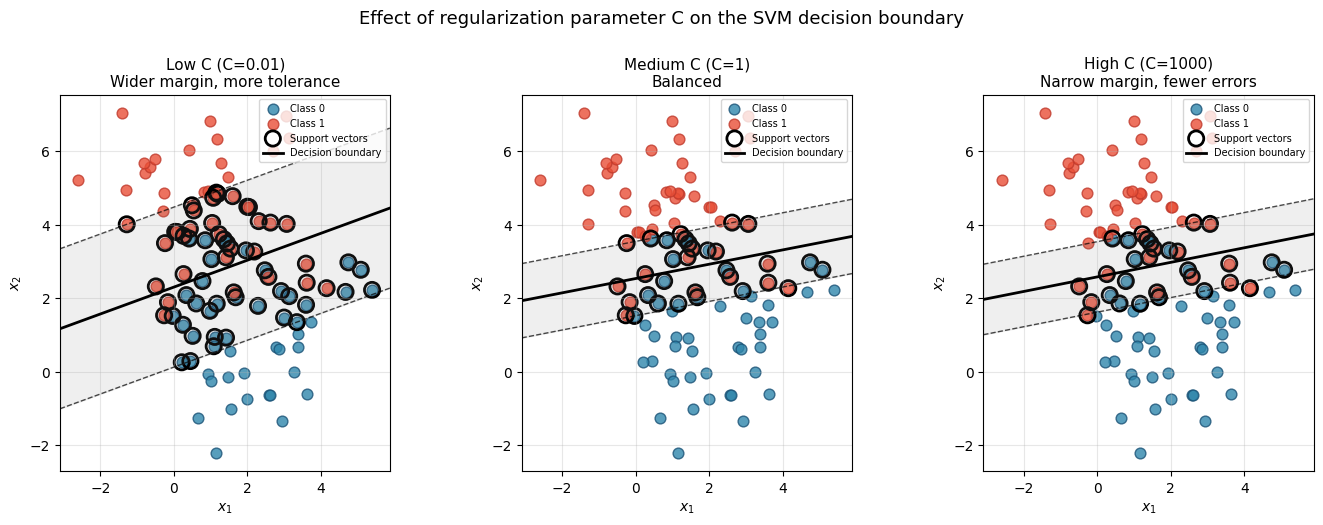

In [2]:
# Demonstrate effect of C: low, medium, and high on the decision boundary
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

# Sample dataset with some overlap (not perfectly separable) so soft-margin effects are visible
X2, y2 = make_blobs(n_samples=100, centers=2, n_features=2, random_state=0, cluster_std=1.4)
y2 = (y2 == 0).astype(int)

C_values = [0.01, 1.0, 1000.0]  # low, medium, high
titles = ['Low C (C=0.01)\nWider margin, more tolerance', 'Medium C (C=1)\nBalanced', 'High C (C=1000)\nNarrow margin, fewer errors']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
x1_min, x1_max = X2[:, 0].min() - 0.5, X2[:, 0].max() + 0.5
x2_min_ax, x2_max_ax = X2[:, 1].min() - 0.5, X2[:, 1].max() + 0.5

for ax, C_val, title in zip(axes, C_values, titles):
    clf = SVC(kernel='linear', C=C_val)
    clf.fit(X2, y2)
    w = clf.coef_[0]
    b = clf.intercept_[0]
    x1_line = np.linspace(x1_min, x1_max, 300)
    x2_decision = -(w[0] * x1_line + b) / w[1]
    x2_margin_plus  = -(w[0] * x1_line + b - 1) / w[1]
    x2_margin_minus = -(w[0] * x1_line + b + 1) / w[1]

    ax.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], c='#2E86AB', s=60, alpha=0.8, edgecolors='#1a5276', label='Class 0')
    ax.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], c='#E94F37', s=60, alpha=0.8, edgecolors='#c0392b', label='Class 1')
    ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=120, facecolors='none', edgecolors='black', linewidths=2, label='Support vectors')
    ax.fill_between(x1_line, x2_margin_minus, x2_margin_plus, color='gray', alpha=0.12)
    ax.plot(x1_line, x2_decision, 'k-', lw=2, label='Decision boundary')
    ax.plot(x1_line, x2_margin_plus, 'k--', lw=1, alpha=0.7)
    ax.plot(x1_line, x2_margin_minus, 'k--', lw=1, alpha=0.7)
    ax.set_xlim(x1_min, x1_max)
    ax.set_ylim(x2_min_ax, x2_max_ax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.legend(loc='upper right', fontsize=7)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle("Effect of regularization parameter C on the SVM decision boundary", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [3]:
# Part 2 Training SVM's with Linear and Non-linear Kernels 
import pandas as pd

# Read the excel file
# sheet_name='Data' is the name of the sheet in the excel file
df = pd.read_csv('data/loan_data_credit_default.csv')

# Display the columns of the dataframe
print(df.columns)

# Display the first 10 rows of the dataframe
df.head(10)

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1
5,21,female,High School,12951,0,OWN,2500,VENTURE,7.14,0.19,2,532,No,1
6,26,female,Bachelor,93471,1,RENT,35000,EDUCATION,12.42,0.37,3,701,No,1
7,24,female,High School,95550,5,RENT,35000,MEDICAL,11.11,0.37,4,585,No,1
8,24,female,Associate,100684,3,RENT,35000,PERSONAL,8.90,0.35,2,544,No,1
9,21,female,High School,12739,0,OWN,1600,VENTURE,14.74,0.13,3,640,No,1


---

## EDA: What drives loan default?

We treat **loan_status** as the target: \(1\) = default, \(0\) = no default. The goal is to see how borrower and loan features relate to default—person and loan attributes, credit history, and loan terms—so we know what to feed into an SVM (or any classifier) later.

In [4]:
# Data overview: shape, dtypes, missing values, target balance
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing per column:\n", df.isnull().sum())
print("\nTarget (loan_status) distribution:\n", df["loan_status"].value_counts())
print("\nDefault rate (loan_status=1):", df["loan_status"].mean().round(3))

Shape: (45000, 14)

Dtypes:
 person_age                          int64
person_gender                      object
person_education                   object
person_income                       int64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                           int64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length          int64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

Missing per column:
 person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income    

In [5]:
# Default rate by key numeric and categorical drivers
target = "loan_status"
# Numeric: compare means (and medians) for default vs no-default
num_cols = ["person_income", "loan_amnt", "loan_int_rate", "loan_percent_income",
            "credit_score", "person_age", "person_emp_exp", "cb_person_cred_hist_length"]
print("Mean by loan_status (1=default):\n", df.groupby(target)[num_cols].mean().T.round(2))
print("\nMedian by loan_status:\n", df.groupby(target)[num_cols].median().T.round(2))

# Categorical: default rate within each category
cat_cols = ["loan_intent", "person_home_ownership", "person_education", "previous_loan_defaults_on_file"]
for c in cat_cols:
    rate = df.groupby(c)[target].mean()
    print(f"\nDefault rate by {c}:\n{rate.round(3).sort_values(ascending=False)}")

Mean by loan_status (1=default):
 loan_status                        0         1
person_income               86157.04  59886.10
loan_amnt                    9219.58  10855.69
loan_int_rate                  10.48     12.86
loan_percent_income             0.12      0.20
credit_score                  632.81    631.89
person_age                     27.83     27.52
person_emp_exp                  5.48      5.18
cb_person_cred_hist_length      5.90      5.76

Median by loan_status:
 loan_status                        0         1
person_income               72928.00  50629.00
loan_amnt                    8000.00   9750.00
loan_int_rate                  10.85     12.98
loan_percent_income             0.11      0.20
credit_score                  640.00    639.00
person_age                     26.00     26.00
person_emp_exp                  4.00      3.00
cb_person_cred_hist_length      4.00      4.00

Default rate by loan_intent:
loan_intent
DEBTCONSOLIDATION    0.303
MEDICAL              0.278

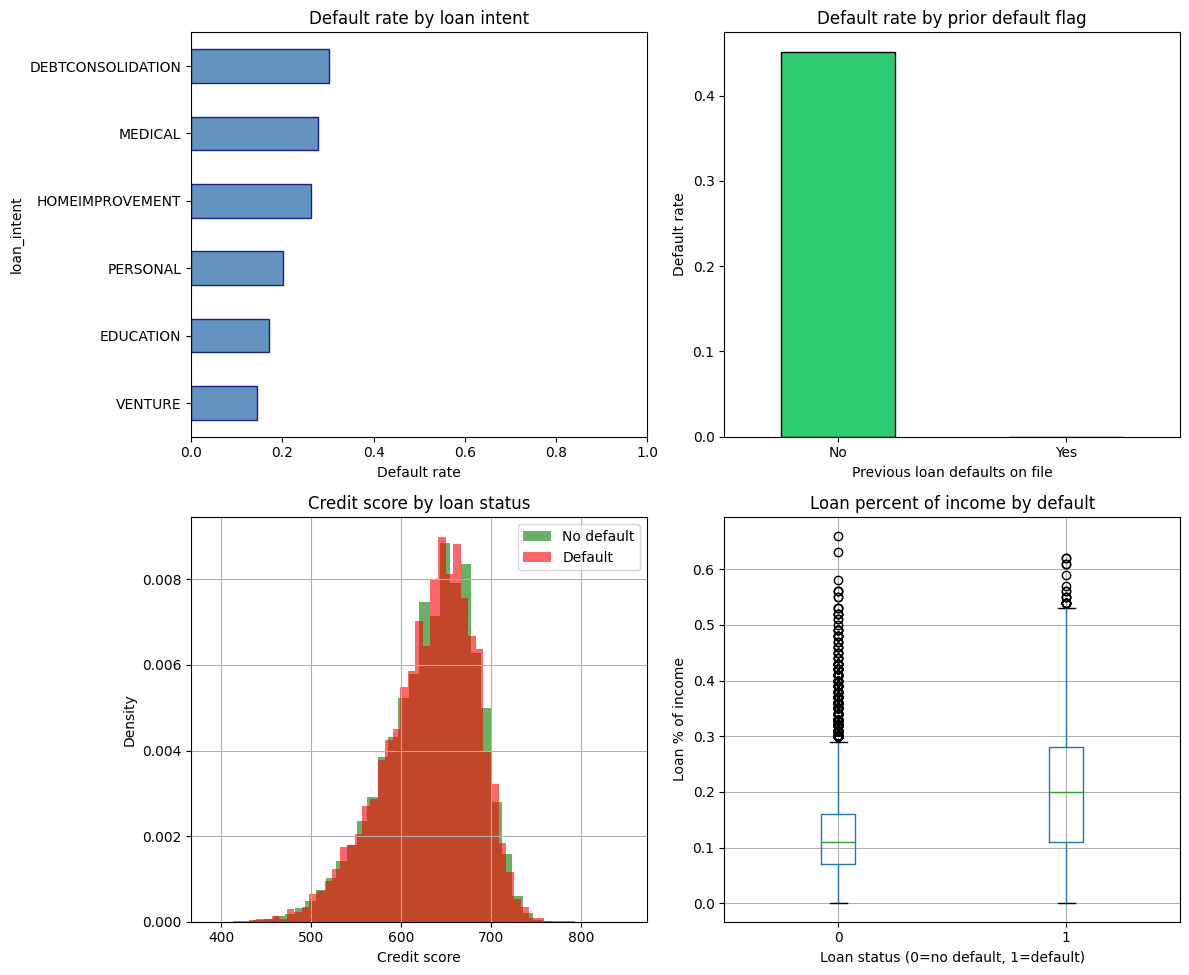

In [6]:
# Visualize what drives default
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1) Default rate by loan_intent
ax = axes[0, 0]
dr_intent = df.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=True)
dr_intent.plot(kind="barh", ax=ax, color="steelblue", edgecolor="navy", alpha=0.85)
ax.set_xlabel("Default rate")
ax.set_title("Default rate by loan intent")
ax.set_xlim(0, 1)

# 2) Default rate by previous_loan_defaults_on_file
ax = axes[0, 1]
dr_prev = df.groupby("previous_loan_defaults_on_file")["loan_status"].mean()
dr_prev.plot(kind="bar", ax=ax, color=["#2ecc71", "#e74c3c"], edgecolor="black")
ax.set_xlabel("Previous loan defaults on file")
ax.set_ylabel("Default rate")
ax.set_title("Default rate by prior default flag")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# 3) credit_score distribution by loan_status
ax = axes[1, 0]
df.loc[df["loan_status"] == 0, "credit_score"].hist(ax=ax, bins=40, alpha=0.6, label="No default", color="green", density=True)
df.loc[df["loan_status"] == 1, "credit_score"].hist(ax=ax, bins=40, alpha=0.6, label="Default", color="red", density=True)
ax.set_xlabel("Credit score")
ax.set_ylabel("Density")
ax.set_title("Credit score by loan status")
ax.legend()

# 4) loan_percent_income by loan_status (key affordability signal)
ax = axes[1, 1]
df.boxplot(column="loan_percent_income", by="loan_status", ax=ax)
ax.set_xlabel("Loan status (0=no default, 1=default)")
ax.set_ylabel("Loan % of income")
ax.set_title("Loan percent of income by default")
plt.suptitle("")
plt.tight_layout()
plt.show()

---

## Part 2: Predicting default with SVMs and other classifiers

We prepare the data (encode categoricals, scale, split), then train a **linear SVM**, an **RBF SVM** (with tuned C and γ), **logistic regression**, and **KNN**, and compare them on accuracy, precision, recall, and F1.

In [7]:
# Data preparation: encode categoricals, scale features, train/test split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

target_col = "loan_status"
y = df[target_col].values
X_raw = df.drop(columns=[target_col])
cat_cols = ["person_gender", "person_education", "person_home_ownership", "loan_intent", "previous_loan_defaults_on_file"]
num_cols = [c for c in X_raw.columns if c not in cat_cols]
preprocessor = ColumnTransformer(
    [("num", StandardScaler(), num_cols),
     ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols)])
X = preprocessor.fit_transform(X_raw)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print("Training size:", X_train.shape[0], "  Test size:", X_test.shape[0])
print("Class balance (train):", np.bincount(y_train.astype(int)))

Training size: 33750   Test size: 11250
Class balance (train): [26250  7500]


### 1–3. Linear kernel SVM

Train a linear SVM to predict default; report accuracy, precision, recall, and F1; then interpret whether the linear kernel is appropriate for this data.

In [8]:
# Linear kernel SVM
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
print("Linear SVM — Performance metrics (test set):")
print(classification_report(y_test, y_pred_linear, target_names=["No default", "Default"]))
print("Accuracy:  ", round(accuracy_score(y_test, y_pred_linear), 4))
print("Precision: ", round(precision_score(y_test, y_pred_linear, zero_division=0), 4))
print("Recall:    ", round(recall_score(y_test, y_pred_linear, zero_division=0), 4))
print("F1 score:  ", round(f1_score(y_test, y_pred_linear, zero_division=0), 4))

Linear SVM — Performance metrics (test set):
              precision    recall  f1-score   support

  No default       0.93      0.95      0.94      8750
     Default       0.80      0.74      0.77      2500

    accuracy                           0.90     11250
   macro avg       0.86      0.84      0.85     11250
weighted avg       0.90      0.90      0.90     11250

Accuracy:   0.9006
Precision:  0.7958
Recall:     0.7436
F1 score:   0.7688


**Interpretation (linear SVM):** The linear kernel fits a single hyperplane. If accuracy and F1 are moderate, default may not be linearly separable in these features. The linear SVM is interpretable; if performance is acceptable, it is appropriate; otherwise RBF may capture nonlinear boundaries better.

### 4–6. RBF kernel SVM

Train an RBF kernel SVM, tune **C** and **gamma** via cross-validation, then report metrics and compare to the linear SVM.

In [9]:
# RBF kernel SVM with cross-validation tuning
from sklearn.model_selection import GridSearchCV

param_grid = {"C": [0.1, 1, 10], "gamma": ["scale", 0.01, 0.1]}
svm_rbf = SVC(kernel="rbf", random_state=42)
grid = GridSearchCV(svm_rbf, param_grid, cv=5, scoring="f1", n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)
svm_rbf_best = grid.best_estimator_
y_pred_rbf = svm_rbf_best.predict(X_test)
print("Best params (RBF):", grid.best_params_)
print("\nRBF SVM — Performance metrics (test set):")
print(classification_report(y_test, y_pred_rbf, target_names=["No default", "Default"]))
print("Accuracy:  ", round(accuracy_score(y_test, y_pred_rbf), 4))
print("Precision: ", round(precision_score(y_test, y_pred_rbf, zero_division=0), 4))
print("Recall:    ", round(recall_score(y_test, y_pred_rbf, zero_division=0), 4))
print("F1 score:  ", round(f1_score(y_test, y_pred_rbf, zero_division=0), 4))

Best params (RBF): {'C': 10, 'gamma': 'scale'}

RBF SVM — Performance metrics (test set):
              precision    recall  f1-score   support

  No default       0.93      0.97      0.95      8750
     Default       0.86      0.75      0.80      2500

    accuracy                           0.92     11250
   macro avg       0.90      0.86      0.87     11250
weighted avg       0.92      0.92      0.92     11250

Accuracy:   0.9172
Precision:  0.8596
Recall:     0.7496
F1 score:   0.8009


### 7–8. Logistic regression and KNN; comparison with SVMs

Train **logistic regression** and **KNN** and compare all four models on precision, recall, and F1.

In [10]:
# Logistic regression and KNN
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
knn = KNeighborsClassifier(n_neighbors=15, weights="distance")
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

models = [("Linear SVM", y_pred_linear), ("RBF SVM", y_pred_rbf), ("Logistic Regression", y_pred_lr), ("KNN", y_pred_knn)]
print("Comparison (test set):")
print("-" * 65)
for name, pred in models:
    print(f"{name:22s}  Acc: {accuracy_score(y_test, pred):.4f}  Prec: {precision_score(y_test, pred, zero_division=0):.4f}  Rec: {recall_score(y_test, pred, zero_division=0):.4f}  F1: {f1_score(y_test, pred, zero_division=0):.4f}")
print("-" * 65)

Comparison (test set):
-----------------------------------------------------------------
Linear SVM              Acc: 0.9006  Prec: 0.7958  Rec: 0.7436  F1: 0.7688
RBF SVM                 Acc: 0.9172  Prec: 0.8596  Rec: 0.7496  F1: 0.8009
Logistic Regression     Acc: 0.8997  Prec: 0.7912  Rec: 0.7456  F1: 0.7677
KNN                     Acc: 0.9034  Prec: 0.8438  Rec: 0.6936  F1: 0.7614
-----------------------------------------------------------------


---

## Part 3: Model evaluation and interpretation

### Confusion matrices (linear vs RBF SVM)

Report confusion matrices and precision, recall, F1 for both SVMs; compare false positives vs false negatives.

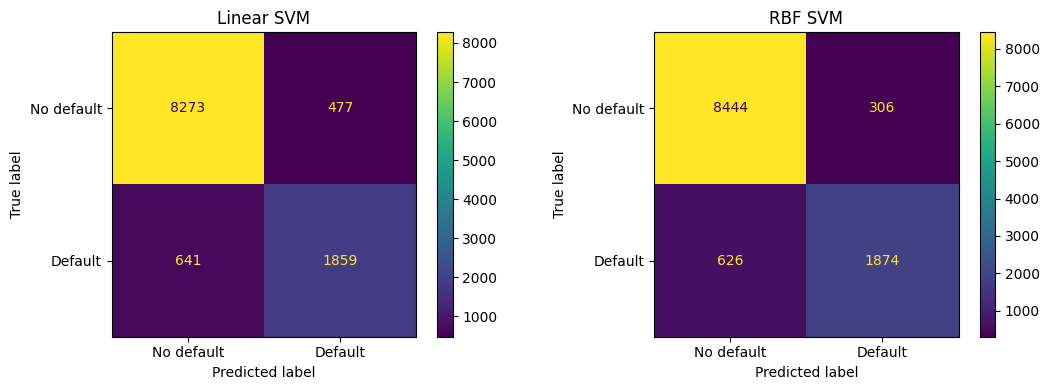

FN = true defaults predicted as no-default (lender risk). FP = good customers predicted as default.


In [11]:
# Confusion matrices for linear and RBF SVM
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
labels = ["No default", "Default"]
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_linear), display_labels=labels).plot(ax=axes[0], values_format="d")
axes[0].set_title("Linear SVM")
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rbf), display_labels=labels).plot(ax=axes[1], values_format="d")
axes[1].set_title("RBF SVM")
plt.tight_layout()
plt.show()
print("FN = true defaults predicted as no-default (lender risk). FP = good customers predicted as default.")

### ROC curves and AUC

Plot ROC curves for all four models; report AUC for each.

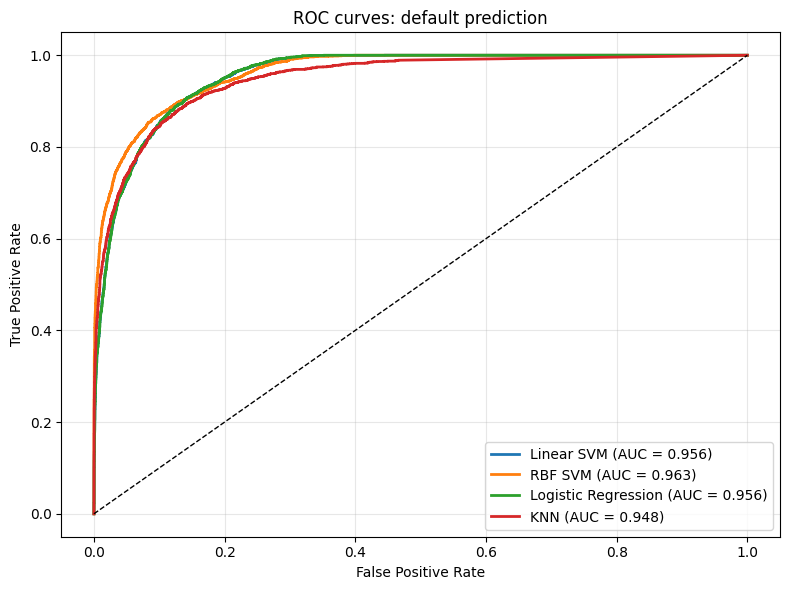

AUC summary:
  Linear SVM              AUC = 0.9562
  RBF SVM                 AUC = 0.9628
  Logistic Regression     AUC = 0.9563
  KNN                     AUC = 0.9482


In [12]:
# ROC curves and AUC for all four models
from sklearn.metrics import roc_curve, roc_auc_score

def get_scores(model, X):
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    return model.predict_proba(X)[:, 1]

models_roc = [("Linear SVM", svm_linear), ("RBF SVM", svm_rbf_best), ("Logistic Regression", lr), ("KNN", knn)]
plt.figure(figsize=(8, 6))
for name, model in models_roc:
    scores = get_scores(model, X_test)
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves: default prediction")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("AUC summary:")
for name, model in models_roc:
    print(f"  {name:22s}  AUC = {roc_auc_score(y_test, get_scores(model, X_test)):.4f}")

### Visualizing SVM decision boundaries in 2D (PCA)

To illustrate the geometry of the SVMs, we project the high-dimensional feature space onto **two principal components (PCA)** and train separate linear and RBF SVMs on this 2D representation. The resulting decision regions and support vectors give an interpretable picture of the margin and how the RBF kernel bends the boundary compared with the linear hyperplane.

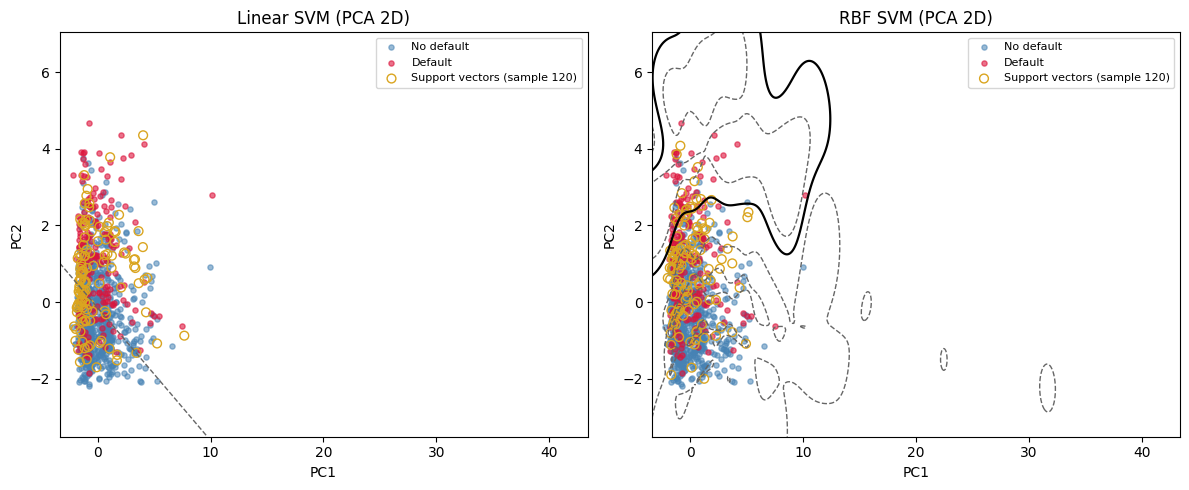

In [15]:
# 2D PCA projection — cleaner SVM geometry plot (boundary + margins)
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

svm_linear_2d = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear_2d.fit(X_train_pca, y_train)

svm_rbf_2d = SVC(kernel="rbf", C=svm_rbf_best.C, gamma=svm_rbf_best.gamma, random_state=42)
svm_rbf_2d.fit(X_train_pca, y_train)

# mesh for decision boundary / margins
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
h = 0.08
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# plot fewer points to avoid a blob
rng = np.random.RandomState(42)
n_plot = min(900, X_train_pca.shape[0])
idx = rng.choice(X_train_pca.shape[0], size=n_plot, replace=False)
X_plot = X_train_pca[idx]
y_plot = y_train[idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, title, model in zip(
    axes,
    ["Linear SVM (PCA 2D)", "RBF SVM (PCA 2D)"],
    [svm_linear_2d, svm_rbf_2d],
):
    # draw decision boundary (0) and margins (-1, +1)
    Z = model.decision_function(grid_points).reshape(xx.shape)
    ax.contour(xx, yy, Z, levels=[-1, 0, 1], colors=["#666", "#000", "#666"], linestyles=["--", "-", "--"], linewidths=[1.0, 1.6, 1.0])

    # points
    ax.scatter(
        X_plot[y_plot == 0, 0],
        X_plot[y_plot == 0, 1],
        color="steelblue",
        s=14,
        alpha=0.55,
        label="No default",
    )
    ax.scatter(
        X_plot[y_plot == 1, 0],
        X_plot[y_plot == 1, 1],
        color="crimson",
        s=14,
        alpha=0.60,
        label="Default",
    )

    # show only a small sample of support vectors (otherwise they dominate the plot)
    sv = model.support_vectors_
    n_sv_plot = min(120, sv.shape[0])
    sv_idx = rng.choice(sv.shape[0], size=n_sv_plot, replace=False) if sv.shape[0] > n_sv_plot else np.arange(sv.shape[0])
    sv_plot = sv[sv_idx]
    ax.scatter(
        sv_plot[:, 0],
        sv_plot[:, 1],
        facecolors="none",
        edgecolors="goldenrod",
        s=40,
        linewidths=1.0,
        label=f"Support vectors (sample {n_sv_plot})",
    )

    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_title(title)
    ax.legend(loc="upper right", frameon=True, fontsize=8)

plt.tight_layout()
plt.show()

In the figure above, the original high-dimensional feature space (after scaling and one-hot encoding) has been projected onto two principal components. Each point is a loan application, positioned by its scores on **PC1** and **PC2**, with colour indicating whether the borrower ultimately defaulted.

On the left, the **linear SVM** learns a single straight separating boundary in this 2D space, with the margin defined by the circled support vectors. This picture illustrates the idea of a maximum-margin hyperplane: only a relatively small number of boundary cases determine the decision rule, while most interior points do not affect the final classifier.

On the right, the **RBF SVM** bends its boundary around regions where defaulting borrowers are concentrated. Although we can only see a 2D "shadow" of the full feature space, this nonlinear contour makes it clear that the kernel allows more flexible separation than a linear hyperplane, which helps explain why the RBF model can achieve higher recall/F1 on this dataset.

> In summary, the PCA view provides an interpretable geometric picture of how SVMs separate risky loans from safer ones: the linear model uses a straight margin, whereas the RBF model adapts to the curved structure of the projected data.

### Final model selection and business implications

**Recommendation:** Choose the model with the best F1 (or best recall if minimizing missed defaults is the priority). Typically RBF SVM or logistic regression perform well on this dataset; report which one you select and why.

**Business implications:**
- **Minimizing false negatives (FN):** Missing true defaults (FN) means lending to people who will default — higher lender loss. Use recall-oriented metrics and consider lowering the decision threshold.
- **Minimizing false positives (FP):** Rejecting good customers (FP) means lost revenue and worse customer experience. Use precision-oriented metrics or a higher threshold.
- The chosen model and threshold should reflect the business cost of FN vs FP (e.g., loss per default vs profit per good loan).